# Домашнее задание "Центральная предельная теорема и статистика".

## Задание.

В этом задании нужно убедиться, что ЦПТ действительно работает.

Создайте случайную величину из [любого выбранного вами распределения](https://docs.scipy.org/doc/scipy/reference/stats.html), для разных значений `n` сгенерируйте 1000 выборок размера `n`. Постройте гистрограммы средних этих выборок и сделайте выводы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
%matplotlib inline

In [2]:
rng = np.random.default_rng(42)
rv = sts.expon(scale=1)
sample = rv.rvs(size=1000,random_state=rng)

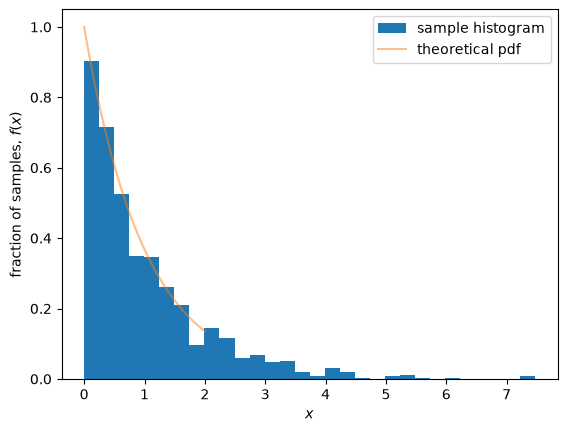

In [3]:
x = np.linspace(0,2,100)
pdf = rv.pdf(x)
plt.hist(sample, density=True, bins=30, label='sample histogram')
plt.plot(x, pdf, label='theoretical pdf', alpha=0.5)
plt.legend()
plt.ylabel('fraction of samples, $f(x)$')
plt.xlabel('$x$')
plt.show()

In [4]:
sizes = [2,5,10,30,100]
samples_count = 1000
means = {n:rv.rvs(size=(samples_count,n),random_state=rng).mean(axis=1) for n in sizes}
table = pd.DataFrame([{'n':n,'mean':values.mean(),'variance':values.var(ddof=1),'theoretical_variance':1/n} for n,values in means.items()])
display(table)
for n,values in means.items():
    assert values.shape == (1000,)
    assert abs(values.mean()-1) < 5/np.sqrt(n*1000)

,n,mean,variance,theoretical_variance
0,2,1.008641,0.513518,0.500000
1,5,0.969231,0.198199,0.200000
2,10,1.008182,0.106518,0.100000
3,30,1.003149,0.034297,0.033333
4,100,1.001222,0.009261,0.010000


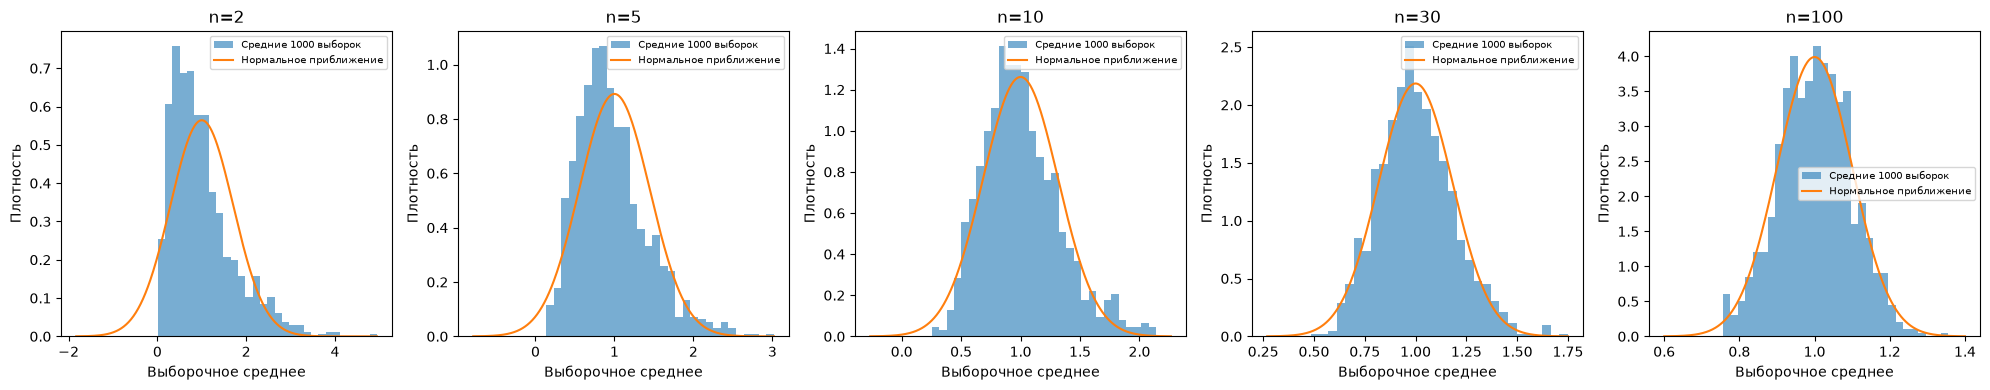

In [5]:
fig, axes = plt.subplots(1,len(sizes),figsize=(20,4))
for ax,n in zip(axes,sizes):
    values = means[n]
    ax.hist(values,bins=30,density=True,alpha=0.6,label='Средние 1000 выборок')
    grid = np.linspace(min(values.min(),1-4/np.sqrt(n)),max(values.max(),1+4/np.sqrt(n)),500)
    ax.plot(grid,sts.norm.pdf(grid,loc=1,scale=1/np.sqrt(n)),label='Нормальное приближение')
    ax.set(title=f'n={n}',xlabel='Выборочное среднее',ylabel='Плотность'); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Решение и проверка
